# Stage 3: Feature Engineering Pipeline (Stages 0-3 outputs)

Rebuilds `nvda_features.parquet` and `nvda_modelling_dataset.parquet` after two fixes:
1. Corwin-Schultz spread is now floored at 0 (the value is 0 whenever the estimator's no-arbitrage assumption is violated by the daily OHLCV approximation).
2. Lempel-Ziv complexity now uses a correct LZ-76 implementation, normalised by `n / log₂ n`, so each rolling window produces meaningful variation in [0, ≈1].

Fractional differentiation was fixed in a previous pass and is not modified here.

In [1]:
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('../')
from src.features import build_feature_matrix

plt.style.use('seaborn-v0_8-darkgrid')
os.makedirs('../reports/figures', exist_ok=True)

## 1. Load Stage 0–2 inputs

In [2]:
df       = pd.read_parquet('../data/processed/nvda_clean.parquet')
fracdiff = pd.read_parquet('../data/processed/nvda_fracdiff.parquet')
events   = pd.read_parquet('../data/processed/nvda_cusum_events.parquet')
labels   = pd.read_parquet('../data/processed/nvda_labels.parquet')
weights  = pd.read_parquet('../data/processed/nvda_sample_weights.parquet')

for name, x in [('clean', df), ('fracdiff', fracdiff), ('events', events),
                ('labels', labels), ('weights', weights)]:
    print(f'{name:8s}: {x.shape}')

clean   : (5113, 8)
fracdiff: (2310, 1)
events  : (400, 0)
labels  : (400, 5)
weights : (400, 1)


## 2. Build the modelling dataset

In [3]:
modelling_dataset = build_feature_matrix(
    df=df, fracdiff=fracdiff, events=events,
    labels=labels, weights=weights,
)
print(f'modelling_dataset shape: {modelling_dataset.shape}')
print(f'columns: {list(modelling_dataset.columns)}')

modelling_dataset shape: (195, 20)
columns: ['ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'momentum_12_1', 'rsi_14', 'vol_20d', 'vol_50d', 'log_dollar_volume', 'volume_ratio', 'corwin_schultz_spread', 'bekker_parkinson_vol', 'amihud_illiquidity', 'roll_spread', 'shannon_entropy', 'lempel_ziv_complexity', 'fracdiff', 'label', 'weight', 't1']


## 3. Validation — microstructure features

In [4]:
with open('_before_stats.json') as f:
    before = json.load(f)

cs = modelling_dataset['corwin_schultz_spread']
lz = modelling_dataset['lempel_ziv_complexity']
bp = modelling_dataset['bekker_parkinson_vol']
am = modelling_dataset['amihud_illiquidity']
rs = modelling_dataset['roll_spread']

def fmt(d, scientific=False):
    fn = (lambda x: f'{x:.3e}') if scientific else (lambda x: f'{x:.4f}')
    keys = ['min', 'max', 'mean', 'std']
    return ' | '.join(f'{k}={fn(d[k])}' for k in keys)

print('=== Corwin-Schultz spread ===')
print(f'BEFORE  {fmt(before["corwin_schultz_spread"])} | n_neg={before["corwin_schultz_spread"]["n_neg"]} | n_zero={before["corwin_schultz_spread"]["n_zero"]}')
print(f'AFTER   min={cs.min():.4f} | max={cs.max():.4f} | mean={cs.mean():.4f} | std={cs.std():.4f} | n_neg={(cs<0).sum()} | n_zero={(cs==0).sum()}')

print()
print('=== Lempel-Ziv complexity ===')
lz_b = before['lempel_ziv_complexity']
print(f'BEFORE  min={lz_b["min"]:.4f} | max={lz_b["max"]:.4f} | mean={lz_b["mean"]:.4f} | std={lz_b["std"]:.4f} | n_unique={lz_b["n_unique"]}')
print(f'AFTER   min={lz.min():.4f} | max={lz.max():.4f} | mean={lz.mean():.4f} | std={lz.std():.4f} | n_unique={lz.nunique()}')

print()
print('=== Bekker-Parkinson volatility ===')
print(f'min={bp.min():.4f} | max={bp.max():.4f} | std={bp.std():.4f}')

print()
print('=== Amihud illiquidity (scientific) ===')
print(f'min={am.min():.3e} | max={am.max():.3e} | std={am.std():.3e}')

print()
print('=== Roll spread ===')
print(f'min={rs.min():.4f} | max={rs.max():.4f} | std={rs.std():.4f} | n_zero={(rs==0).sum()}')

=== Corwin-Schultz spread ===
BEFORE  min=-0.4776 | max=0.1022 | mean=-0.0506 | std=0.0808 | n_neg=121 | n_zero=0
AFTER   min=0.0000 | max=0.1022 | mean=0.0081 | std=0.0180 | n_neg=0 | n_zero=140

=== Lempel-Ziv complexity ===
BEFORE  min=1.0000 | max=1.0000 | mean=1.0000 | std=0.0000 | n_unique=1
AFTER   min=0.9030 | max=1.4674 | mean=1.2301 | std=0.0992 | n_unique=6

=== Bekker-Parkinson volatility ===
min=0.0003 | max=0.0099 | std=0.0018

=== Amihud illiquidity (scientific) ===
min=5.316e-13 | max=4.189e-11 | std=5.704e-12

=== Roll spread ===
min=0.0000 | max=8.2117 | std=1.6174 | n_zero=71


## 4. NaN / Inf check across every column

In [5]:
issues = pd.DataFrame({
    'n_nan': modelling_dataset.isna().sum(),
    'n_inf': np.isinf(modelling_dataset.select_dtypes(include='number')).sum(),
})
issues['has_issue'] = (issues['n_nan'] > 0) | (issues['n_inf'] > 0)
if issues['has_issue'].any():
    print('!! columns with NaN or Inf:')
    print(issues[issues['has_issue']])
else:
    print('No NaNs or Infs in any column.')
issues.drop(columns='has_issue')

No NaNs or Infs in any column.


,n_nan,n_inf
amihud_illiquidity,0,0.0
bekker_parkinson_vol,0,0.0
corwin_schultz_spread,0,0.0
fracdiff,0,0.0
label,0,0.0
lempel_ziv_complexity,0,0.0
log_dollar_volume,0,0.0
momentum_12_1,0,0.0
ret_10d,0,0.0
ret_20d,0,0.0


## 5. Conditional drop of Lempel-Ziv if still degenerate

If `std == 0` after the LZ-76 fix the feature still carries no signal and is removed from both saved parquets, with the reason logged. Otherwise it is kept.

In [6]:
lz_std = float(modelling_dataset['lempel_ziv_complexity'].std())
lz_unique = int(modelling_dataset['lempel_ziv_complexity'].nunique())

drop_lz = (lz_std == 0) or (lz_unique <= 1)
if drop_lz:
    print(f'Dropping lempel_ziv_complexity: std={lz_std:.6f}, '
          f'n_unique={lz_unique}. Reason: still non-informative '
          'after the LZ-76 fix.')
    modelling_dataset = modelling_dataset.drop(columns=['lempel_ziv_complexity'])
else:
    print(f'Keeping lempel_ziv_complexity: std={lz_std:.6f}, '
          f'n_unique={lz_unique}.')

print()
print(f'final modelling_dataset shape:    {modelling_dataset.shape}')
feature_cols = [c for c in modelling_dataset.columns if c not in ('label','weight','t1')]
print(f'final features ({len(feature_cols)}):')
for c in feature_cols:
    print(f'  - {c}')

Keeping lempel_ziv_complexity: std=0.099238, n_unique=6.

final modelling_dataset shape:    (195, 20)
final features (17):
  - ret_5d
  - ret_10d
  - ret_20d
  - ret_60d
  - momentum_12_1
  - rsi_14
  - vol_20d
  - vol_50d
  - log_dollar_volume
  - volume_ratio
  - corwin_schultz_spread
  - bekker_parkinson_vol
  - amihud_illiquidity
  - roll_spread
  - shannon_entropy
  - lempel_ziv_complexity
  - fracdiff


## 6. P11 — feature correlation heatmap

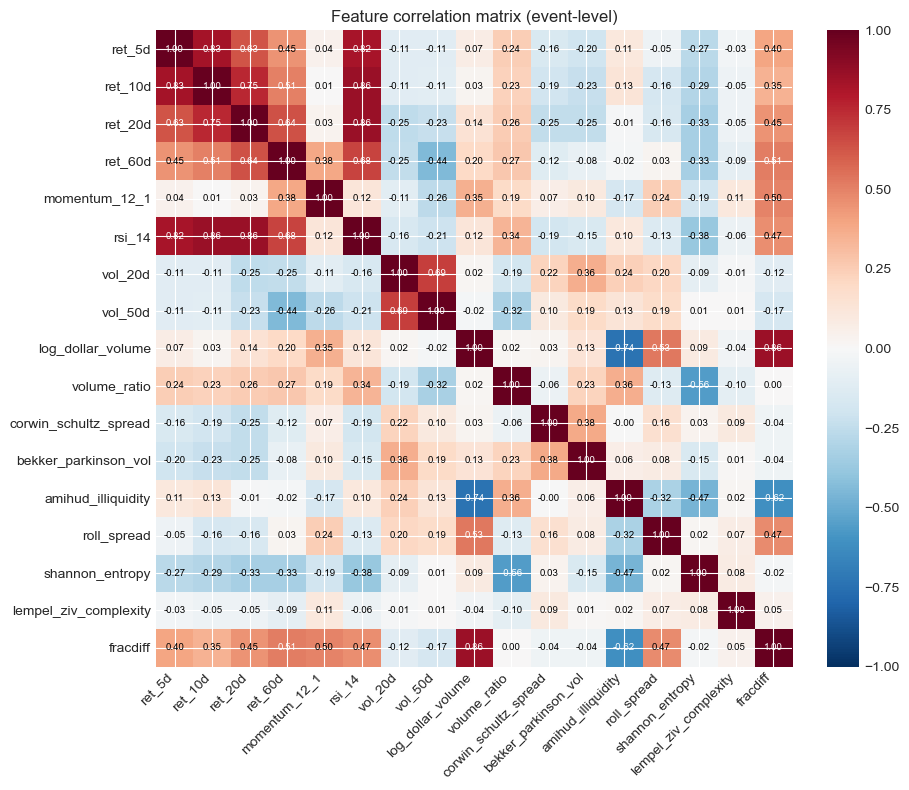

In [7]:
feature_only = modelling_dataset[feature_cols]
corr = feature_only.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        v = corr.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='white' if abs(v) > 0.5 else 'black', fontsize=7)
ax.set_title('Feature correlation matrix (event-level)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig('../reports/figures/P11_feature_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 7. Save outputs

In [8]:
feature_cols = [c for c in modelling_dataset.columns if c not in ('label','weight','t1')]
features_only = modelling_dataset[feature_cols]

features_only.to_parquet('../data/processed/nvda_features.parquet')
modelling_dataset.to_parquet('../data/processed/nvda_modelling_dataset.parquet')

print('Saved:')
print(f'  ../data/processed/nvda_features.parquet           {features_only.shape}')
print(f'  ../data/processed/nvda_modelling_dataset.parquet  {modelling_dataset.shape}')
print(f'  ../reports/figures/P11_feature_correlation_heatmap.png')

Saved:
  ../data/processed/nvda_features.parquet           (195, 17)
  ../data/processed/nvda_modelling_dataset.parquet  (195, 20)
  ../reports/figures/P11_feature_correlation_heatmap.png


## 8. Notes on staleness

Because the feature columns now carry corrected values, the existing Stage 4/5/6 artefacts are stale until those notebooks are re-run:

- `models/model_rf.pkl`, `models/model_xgb.pkl`, `models/model_final.pkl`
- `models/best_params.json`
- `data/processed/cv_results.parquet`
- `data/processed/tuning_log.parquet`
- `data/processed/feature_importance.parquet`

Recommended order to refresh: notebook 06 → 09 → 08.